# ECBM E4070/6070 2026 Spring Homework #2

Author: [Shashwat Shukla](shashwat.shukla@columbia.edu), [Bruce Yi Bu](yb2520@columbia.edu)

## Names and UNI

- Ciro Randazzo (cr3510)
- Alexander Speer (aes2376)


## Task 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# make sure the states x1,x2,x3 are within range (0,1)
def zo(x):
    return np.minimum(np.maximum(0.0, x), 1.0)


class HHNS:
    """Non-spiking Hodgkin-Huxley-like membrane model (HHNS)

    This class implements ONLY the membrane + gating ODEs.
    The upstream RPM/TRP block should be implemented separately by students
    to generate the injected current I(t) in (uA/cm^2) (or consistent units).

    Instantiate:
        hh = HHNS()

    Access V at a particular step:
        V = hh.x[0]

    Step the model:
        hh.step(dt, I[i+1])   # dt in seconds, I is injected current at this step

    State vector order:
        x = [V, sa, si, dra, dri, nov]
        where V is membrane potential (mV) and gates are unitless in [0,1].
    """

    def __init__(self):
        # Default initial conditions taken from your CUDA kernel
        V0 = 0.0
        sa0 = 0.2184
        si0 = 0.9653
        dra0 = 0.0117
        dri0 = 0.9998
        nov0 = 0.0017

        self.x = [V0, sa0, si0, dra0, dri0, nov0]

    def step(self, dt, I, x=None):
        """HHNS membrane + gating update for one time step.

        Args:
            dt: time step in seconds (the HHNS kinetics here operate on ms)
            I:  injected current at this step (same role as I_trp in your kernel)
            x:  optional state vector to use instead of self.x

        Returns:
            Updated state vector [V, sa, si, dra, dri, nov]
        """
        ddt = dt * 1000.0  # model operates on ms, convert s -> ms

        if x is None:
            x = self.x

        V, sa, si, dra, dri, nov = x

        # HHNS parameters
        E_K = -85.0
        E_Cl = -30.0
        G_s = 1.6
        G_dr = 3.5
        G_Cl = 0.006
        G_K = 0.082
        G_nov = 3.0
        C = 4.0

        # sa gate
        x_inf = (1.0 / (1.0 + np.exp((-23.7 - V) / 12.8))) ** (1.0 / 3.0)
        tau_x = 0.13 + 3.39 * np.exp(-((-73.0 - V) ** 2) / 400.0)
        dsa = (x_inf - sa) / tau_x

        # si gate
        x_inf = 0.9 / (1.0 + np.exp((-55.0 - V) / -3.9)) + 0.1 / (
            1.0 + np.exp((-74.8 - V) / -10.7)
        )
        tau_x = 113.0 * np.exp(-((-71.0 - V) ** 2) / 841.0)
        dsi = (x_inf - si) / tau_x

        # dra gate
        x_inf = np.sqrt(1.0 / (1.0 + np.exp((-1.0 - V) / 9.1)))
        tau_x = 0.5 + 5.75 * np.exp(-((-25.0 - V) ** 2) / 1024.0)
        ddra = (x_inf - dra) / tau_x

        # dri gate
        x_inf = 1.0 / (1.0 + np.exp((-25.7 - V) / -6.4))
        tau_x = 890.0
        ddri = (x_inf - dri) / tau_x

        # nov gate
        x_inf = 1.0 / (1.0 + np.exp((-12.0 - V) / 11.0))
        tau_x = 3.0 + 166.0 * np.exp(-((-20.0 - V) ** 2) / 484.0)
        dnov = (x_inf - nov) / tau_x

        # Membrane equation
        dV = (
            I
            - G_K * (V - E_K)
            - G_Cl * (V - E_Cl)
            - G_s * (sa**3) * si * (V - E_K)
            - G_dr * (dra**2) * dri * (V - E_K)
            - G_nov * nov * (V - E_K)
        ) / C

        # Next step updates
        V = V + ddt * dV
        sa = zo(sa + ddt * dsa)
        si = zo(si + ddt * dsi)
        dra = zo(dra + ddt * ddra)
        dri = zo(dri + ddt * ddri)
        nov = zo(nov + ddt * dnov)

        x = [V, sa, si, dra, dri, nov]
        self.x = x
        return x

In [2]:
# define photoreceptor


class Photoreceptor:

    def __init__(self, **params):

        self.params = {}

        # default params
        self.params["a1"] = 0.0001
        self.params["b1"] = 279.6

        self.params["a2"] = 150.5
        self.params["b2"] = 819.8
        self.params["k2"] = 30.0

        self.params["a3"] = 819.8
        self.params["b3"] = 4.51

        self.params["c"] = 0.51
        self.params["n"] = 2
        self.params["g_trp"] = 1500
        self.params["E_trp"] = 0

        # overwrite custom
        for k, v in params.items():
            if k not in self.params.keys():
                raise KeyError(f"Unrecognized parameter: {k}")
            else:
                self.params[k] = v

        return

    def solve(self, li, t, dt, xi=[0, 0, 0]):

        self.t = np.squeeze(t)
        self.li = li
        self.dt = dt

        assert (
            self.t.shape == self.li.shape
        ), "Time and light input must have same shape!"

        # initialize x, I
        xi = np.array(xi).squeeze()
        assert xi.shape == (3,), "xi must have shape (3,): [x1, x2, x3]"

        self.x = np.zeros(shape=(len(t), 3))
        self.x[0, :] = xi

        self.I = np.zeros(shape=(len(t),))

        # reinitialize membrane + voltage
        self.membrane_model = HHNS()
        self.V = np.zeros(shape=(len(t),))
        self.V[0] = self.membrane_model.x[0]

        for i in range(1, len(t)):
            self.step(i)

        return self.x, self.I, self.V

    def step(self, i):
        ll = self.li[i]  # instantaneous light level

        # step photoreceptor dynamics
        dxdt = [self.dx1dt(i, ll), self.dx2dt(i), self.dx3dt(i)]
        dx = self.dt * np.array(dxdt)

        # update states and clamp to [0,1] range
        self.x[i, :] = zo(self.x[i - 1, :] + dx)

        # find input current to photo-insensitive cell membrane
        I = self.photo_current(i)
        self.I[i] = I

        # step membrane voltage
        membrane_state = self.membrane_model.step(self.dt, I)
        self.V[i] = membrane_state[0]

    def dx1dt(self, i, ll):
        x1, _, _ = self.x[i - 1, :]

        a1 = self.params["a1"]
        b1 = self.params["b1"]

        return (a1 * ll * (1 - x1)) - (b1 * x1)

    def dx2dt(self, i):
        x1, x2, x3 = self.x[i - 1, :]

        a2 = self.params["a2"]
        b2 = self.params["b2"]
        k2 = self.params["k2"]

        return (a2 * x1 * (1 - x2)) - (b2 * x2) - (k2 * x2 * x3)

    def dx3dt(self, i):
        _, x2, x3 = self.x[i - 1, :]

        a3 = self.params["a3"]
        b3 = self.params["b3"]

        return (-a3 * x3) + (b3 * x2)

    def photo_current(self, i):
        """compute instantaneous membrane current due to photoreceptivity"""
        _, x2, _ = self.x[i - 1, :]

        n = self.params["n"]
        c = self.params["c"]
        g_trp = self.params["g_trp"]
        E_trp = self.params["E_trp"]

        V = self.V[i - 1]

        div_norm = x2**n / (x2**n + c**n)
        return div_norm * g_trp * (E_trp - V)

In [3]:
def plot_photoreceptor_timeseries(pr, figsize=(10, 6)):
    """
    Plot the timeseries of light input and membrane voltage for a Photoreceptor.

    Args:
        pr: Photoreceptor object that has been solved (has attributes t, li, V)

    The plot shows:
        - Voltage (V) on the left y-axis
        - Light intensity (li) on the right y-axis
        - Time on the shared x-axis

    Credit: Generated by Cursor AI.
    """
    fig, ax1 = plt.subplots(figsize=figsize)

    # Plot voltage on left axis
    color = "tab:orange"
    ax1.set_xlabel("Time (s)", fontsize=12)
    ax1.set_ylabel("Membrane Voltage (mV)", color=color, fontsize=12)
    line1 = ax1.plot(pr.t, pr.V, color=color, label="Voltage", linewidth=1.5)
    ax1.tick_params(axis="y", labelcolor=color)
    ax1.grid(True, alpha=0.3)

    # Create second y-axis for light intensity
    ax2 = ax1.twinx()
    color = "tab:blue"
    ax2.set_ylabel("Light Intensity", color=color, fontsize=12)
    line2 = ax2.plot(
        pr.t, pr.li, color=color, label="Light Input", linewidth=1.5, alpha=0.7
    )
    ax2.tick_params(axis="y", labelcolor=color)

    # Add legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper right")

    plt.title("Photoreceptor Timeseries: Voltage and Light Input", fontsize=14, pad=20)
    fig.tight_layout()
    plt.show()

    return fig, (ax1, ax2)

In [4]:
# Time vector
dt = 1e-5  # time unit is s, aka dt=0.00001s
t = np.arange(0, 2, dt)

# define light
background_level = 1e6

# suppress formatter for list
# fmt: off
light_levels = [
    1e1, 5e1, 1e2, 5e2, 1e3, 5e3,
    1e4, 5e4, 1e5, 5e5, 1e6, 5e6,
    1e7, 5e7, 1e8, 5e8, 1e9,
]
# fmt: on

In [5]:
# run simulations
#
# ~3min for all, i7 macbook pro

prs = {ll: Photoreceptor() for ll in light_levels}

for ll, pr in prs.items():
    print(f"Solving: ll={ll:.1e}")
    # define light input vectors
    li = np.ones_like(t) * background_level
    li[100000:] = ll

    x, I, V = pr.solve(li, t, dt, xi=[0, 0, 0])

Solving: ll=1.0e+01
Solving: ll=5.0e+01
Solving: ll=1.0e+02
Solving: ll=5.0e+02
Solving: ll=1.0e+03
Solving: ll=5.0e+03
Solving: ll=1.0e+04
Solving: ll=5.0e+04
Solving: ll=1.0e+05
Solving: ll=5.0e+05
Solving: ll=1.0e+06
Solving: ll=5.0e+06
Solving: ll=1.0e+07
Solving: ll=5.0e+07
Solving: ll=1.0e+08
Solving: ll=5.0e+08
Solving: ll=1.0e+09


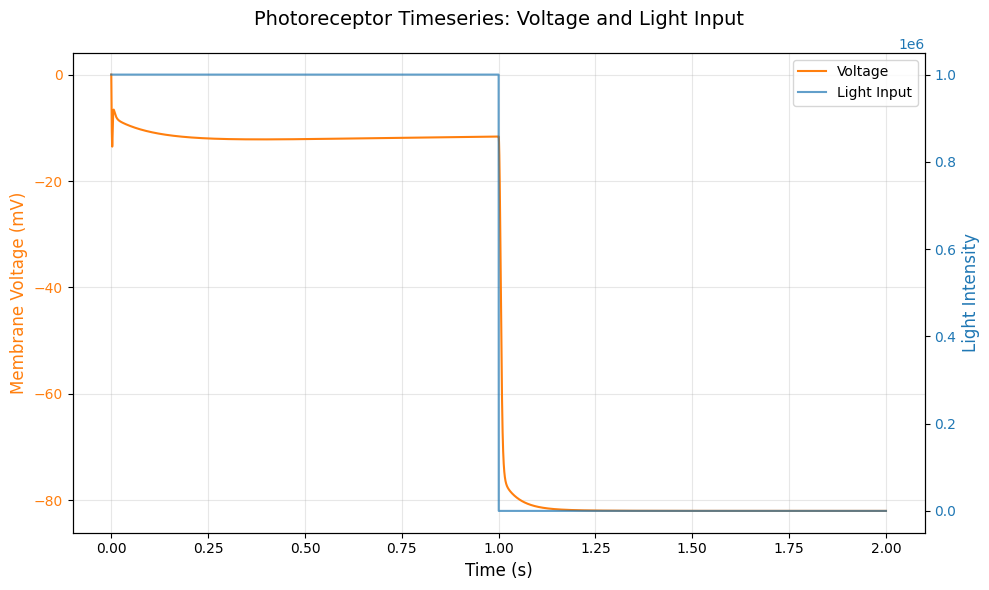

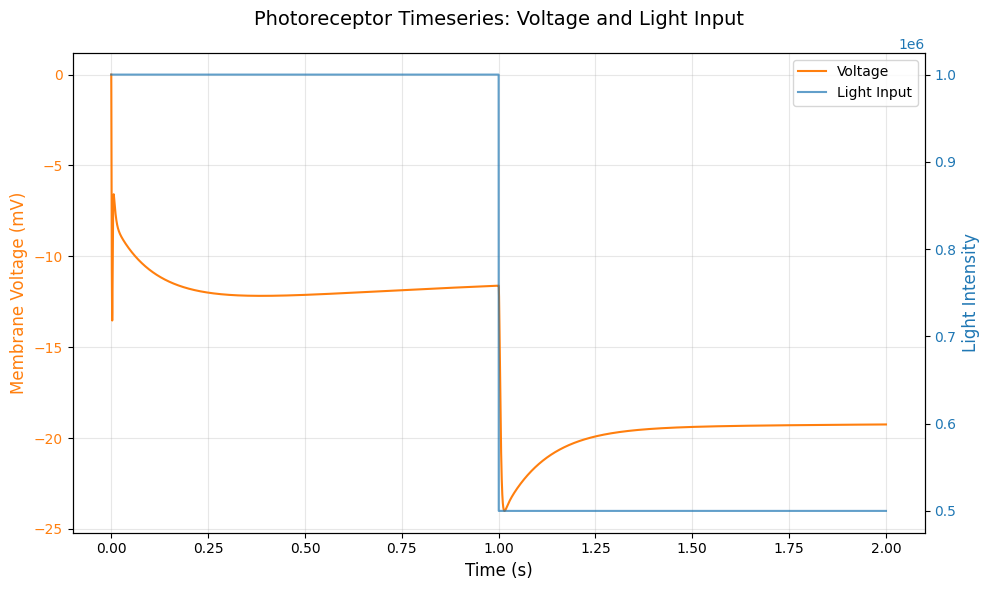

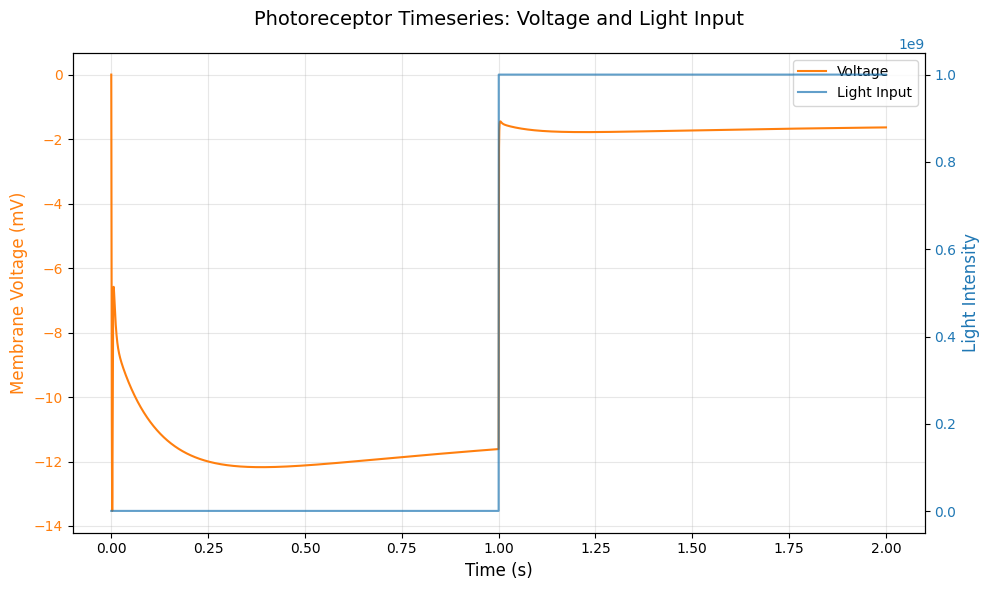

In [6]:
for ll in [1e1, 5e5, 1e9]:
    fig, axs = plot_photoreceptor_timeseries(prs[ll])

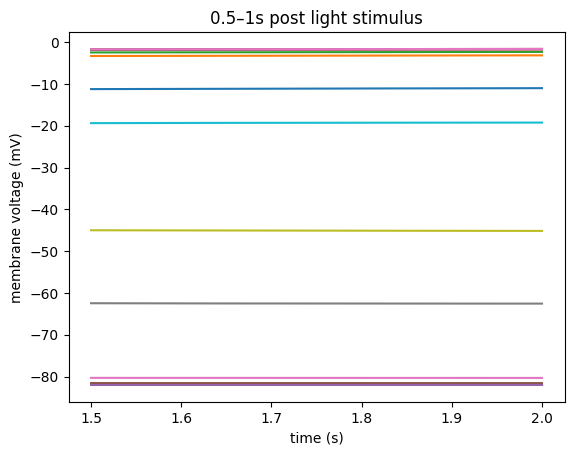

In [7]:
# manual inspection of steady state response

fig, ax = plt.subplots()

for ll, pr in prs.items():
    ii = pr.t > 1.5

    x = pr.t[ii]
    y = pr.V[ii]

    ax.plot(x, y, label=f"{ll:.1e}")

ax.set(
    xlabel="time (s)",
    ylabel="membrane voltage (mV)",
    title="0.5–1s post light stimulus",
)

plt.show()

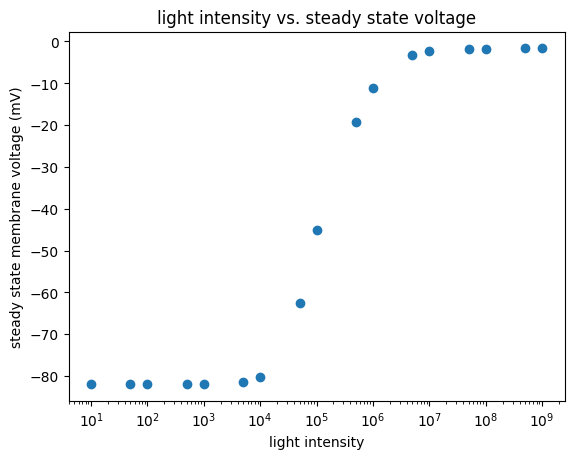

In [8]:
# plot light intensity (on log scale, 10 as base) vs steady state voltage
# (it helps to additionally plt in a plot each experiment's voltage vs time,
# you do not want to see consistent spikes)

# from previous plot: last value is reasonable for all stimuli

V_ss = {ll: pr.V[-1] for ll, pr in prs.items()}

fig, ax = plt.subplots()
ax.set_xscale("log")
ax.scatter(list(V_ss.keys()), list(V_ss.values()))

ax.set(
    xlabel="light intensity",
    ylabel="steady state membrane voltage (mV)",
    title="light intensity vs. steady state voltage",
)

plt.show()

I believe that the relationship between the light intensity and the steady-state membrane voltage is going to end up as sigmoidal when plotted on a log light axis. For example, at low light intensities, the TRP current is small since the divisive normalization term is able to keep the channel conductance effectively low, so that the HHNS membrane stays near a strongly hyperpolarized steady state (which is also around the lower plateau). And then, as the light intensity increases towards a more intermediate range, the photoreceptor state variable that controls the TRP conductance actually rises enough so that the injected current increases rapidly, which then has the effect of producing a steep change in the membrane voltage. At the very high light intensities, the response saturates, meaning that the divisive normalization manages to drive the conductance term toward its maximum (essentially bounded by the normalization), so that any sort of further increases in light are only able to produce small additional changes in current, and the voltage approaches an upper plateau. Overall, I would say that the model compresses a wide dynamic range of light intensities into a more bounded voltage range, which then yields the characteristic S-shaped curve.


## Task 2
### Part 1

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from math import exp, sqrt
from numpy import cbrt

In [10]:
# hint:
# note that for this question since the inputs stimulants are constants,
# convolution with filters is equivalent to multiplying the input with the
# time integral of said filters

# TODO: implement the kernels and DNP (no feedback, only feedforward) here


def constant_photoreceptor_output(
    u,
    t,
    b1=0.1,
    a1=0.1,
    c1=0.1,
    b2=0.1,
    a2=0.1,
    c2=0.1,
):

    # construct volterra kernels
    h11 = lambda t: a1 * t / 0.1 * np.exp(-t / 0.1)

    h21 = lambda t: c1 * t / 0.2 * np.exp(-t / 0.2)

    # since constant, take time integrals
    assert np.isscalar(u)

    integral_h11 = np.trapz(h11(t), t)
    integral_h12 = a2 * 1e-4 * (integral_h11**2)
    T1u = b1 + integral_h11 * u + integral_h12 * (u**2)

    integral_h21 = np.trapz(h21(t), t)
    integral_h22 = c2 * 1e-4 * (integral_h21**2)
    T2u = b2 + integral_h21 * u + integral_h22 * (u**2)

    v = T1u / T2u

    return v

In [11]:
sweep = [1e-4, 1e-2, 0.1, 1, 10, 100]

dt = 1e-4
t = np.arange(0, 0.5, dt)
u = 1e3

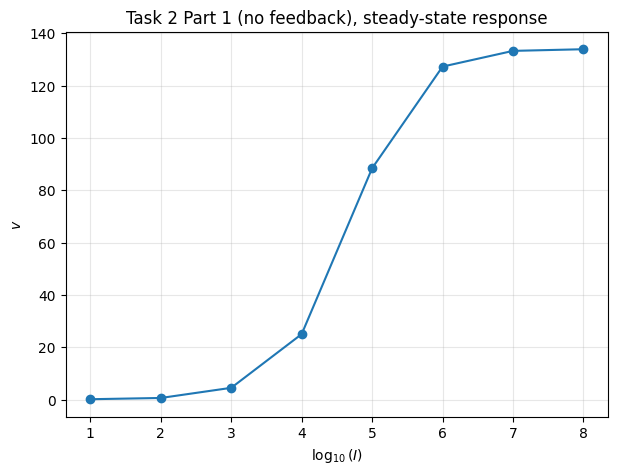

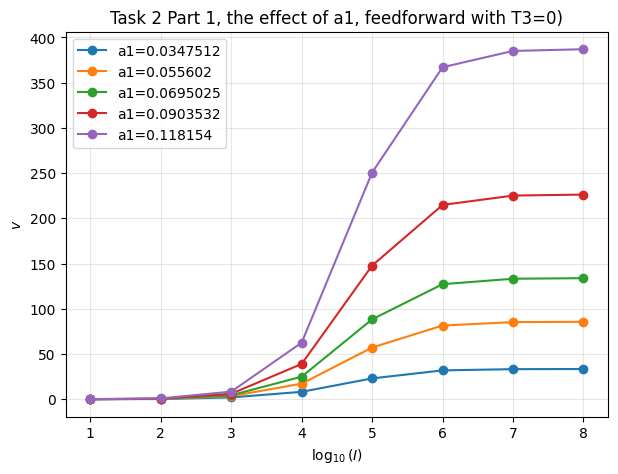

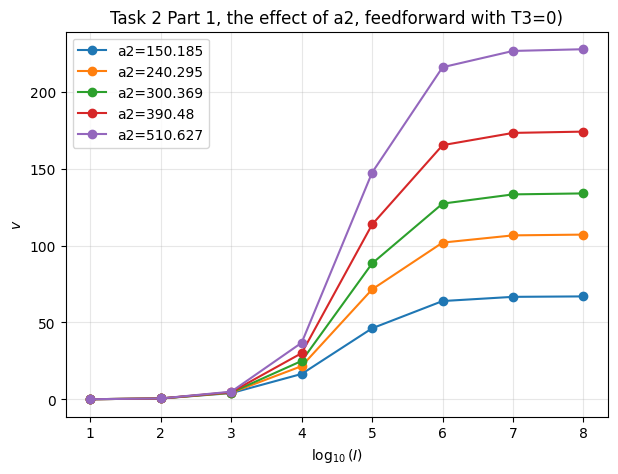

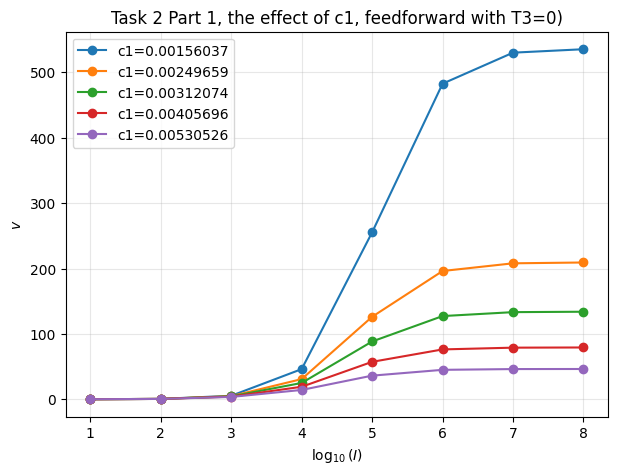

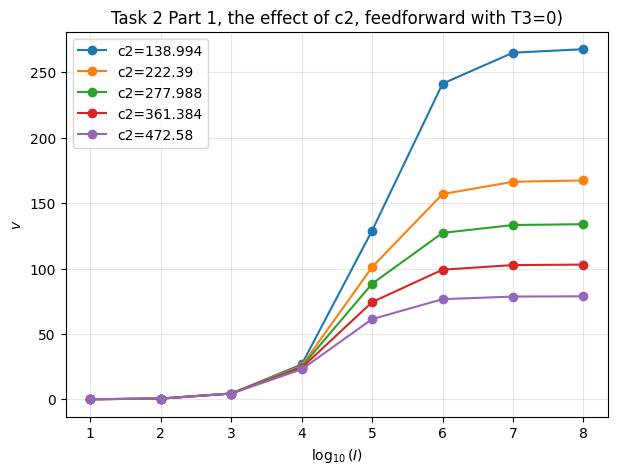

Low-I approx v ≈ b1/b2 = 0.0640679822820582
High-I approx v ≈ H12/H22 = 133.98455744154506


In [12]:
#Hi ciro this is my implementation here

import numpy as np
import matplotlib.pyplot as plt

# all of the intensities that are required by prompt: 10, 10^2, ..., 10^8
I_vals = 10.0 ** np.arange(1, 9)
logI = np.log10(I_vals)

def steady_state_v_feedforward(I, b1, b2, a1, a2, c1, c2):
    H11 = a1 * 0.1
    H21 = c1 * 0.2
    H12 = a2 * 1e-4 * (H11**2)
    H22 = c2 * 1e-4 * (H21**2)
    T1 = b1 + H11*I + H12*(I**2)
    T2 = b2 + H21*I + H22*(I**2)
    return T1 / T2

def v_curve(I_array, params):
    I_array = np.asarray(I_array, dtype=float)
    return steady_state_v_feedforward(I_array, **params)

# Here are our baseline parameters that are doing to be tweaked throughout:
# (they're going to be chosen once and then held fixed in ALL sweeps except the parameter being swept.
#then there is an extra paragraph about this at the end of this code cell
base = dict(
    b1=0.080709,
    b2=1.25974,
    a1=0.0695025,
    a2=300.369,
    c1=0.00312074,
    c2=277.988,
)

# here is the baseline plot
v_base = v_curve(I_vals, base)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(logI, v_base, marker="o")
ax.set(
    title="Task 2 Part 1 (no feedback), steady-state response",
    xlabel=r"$\log_{10}(I)$",
    ylabel=r"$v$",
)
ax.grid(True, alpha=0.3)
plt.show()

# the parameter sweeps,
sweeps = {
    "a1": [0.5*base["a1"], 0.8*base["a1"], base["a1"], 1.3*base["a1"], 1.7*base["a1"]],
    "a2": [0.5*base["a2"], 0.8*base["a2"], base["a2"], 1.3*base["a2"], 1.7*base["a2"]],
    "c1": [0.5*base["c1"], 0.8*base["c1"], base["c1"], 1.3*base["c1"], 1.7*base["c1"]],
    "c2": [0.5*base["c2"], 0.8*base["c2"], base["c2"], 1.3*base["c2"], 1.7*base["c2"]],
}

for pname, pvals in sweeps.items():
    fig, ax = plt.subplots(figsize=(7,5))
    for pv in pvals:
        params = dict(base)
        params[pname] = float(pv)
        v = v_curve(I_vals, params)
        ax.plot(logI, v, marker="o", label=f"{pname}={pv:.6g}")

    ax.set(
        title=f"Task 2 Part 1, the effect of {pname}, feedforward with T3=0)",
        xlabel=r"$\log_{10}(I)$",
        ylabel=r"$v$",
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

# plrove that its saturating



H11 = base["a1"]*0.1
H21 = base["c1"]*0.2
H12 = base["a2"]*1e-4*(H11**2)
H22 = base["c2"]*1e-4*(H21**2)
print("Low-I approx v ≈ b1/b2 =", base["b1"]/base["b2"])
print("High-I approx v ≈ H12/H22 =", H12/H22)

A brief note on the nature of the X and Y axis:

From what I could find, all of the large values on the y-axis seem to arise naturally from the steady-state structure of the feedforward divisive normalization model. It seems that for constant input $I$, the response is going to have the form

$$
v(I)=\frac{b_1+H_{11}I+H_{12}I^2}{b_2+H_{21}I+H_{22}I^2}.
$$

And then at high light intensities, I believe that the quadratic terms dominate, meaning that the response approaches the constant limit

$$
v(\infty)\approx \frac{H_{12}}{H_{22}}.
$$

And then because of the second-order gains depend on $(a_1,a_2,c_1,c_2)$ through

$$
\frac{H_{12}}{H_{22}}=\frac{a_2}{c_2}\left(\frac{a_1}{2c_1}\right)^2,
$$

It seems to me that certain parameter combinations can make this ratio much larger than 1. In that regime I believe that the circuit still exhibits a sigmoidal, saturating response as a function of $\log I$, but the upper plateau occurs at a very large value. It seems like the “blown-out” y-axis reflects the magnitude of our kernel gains rather than an error in the implementation.

# **Part 2**

The steady-state response for a constant input  
Let us assume that this is a feedforward only model (meaning that $T^3 = 0$).

That would mean that. from Lecture 3 (the feedforward DNP I/O slide), the divisive normalization model without feedback is going to be:

$$
v(t) = \frac{(T^1 u)(t)}{(T^2 u)(t)}.
$$

The first step is going to be writing each $T^k$ using the Volterra expansion

From Lecture 3, we are aware that each operator $T^k$ (for $k \in \{1,2\}$) can also be written as a second-order Volterra operator as follows:

$$
(T^k u)(t)
=
b_k
+
\int_{0}^{\infty} h_1^k(\tau)\, u(t-\tau)\, d\tau
+
\int_{0}^{\infty}\int_{0}^{\infty}
h_2^k(\tau_1,\tau_2)\,
u(t-\tau_1)\,
u(t-\tau_2)\,
d\tau_1 d\tau_2.
$$

(And this form comes directly from the Lecture 3 notes on the I/O of the single-channel DNP.)

The second step is going to be plugging in constant input $u(t)=u_0$

If the input is constant, then for any $\tau \ge 0$,

$$
u(t-\tau) = u_0.
$$

This would mean that both integrals are going to become constants:

$$
(T^k u)(t)
=
b_k
+
\left( \int_{0}^{\infty} h_1^k(\tau)\, d\tau \right) u_0
+
\left( \int_{0}^{\infty}\int_{0}^{\infty}
h_2^k(\tau_1,\tau_2)\, d\tau_1 d\tau_2
\right) u_0^2.
$$

The third step is then to define the steady-state gains (per the homework hint)

Let us define

$$
H_1^k := \int_{0}^{\infty} h_1^k(t)\, dt,
\qquad
H_2^k := \int_{0}^{\infty}\int_{0}^{\infty}
h_2^k(t_1,t_2)\, dt_1 dt_2.
$$

These are actually the DC gains of the first- and second-order kernels (Taken from Lecture 3 steady-state discussion).

So that would mean that the steady-state output of each block is going to end up becoming

$$
T_\infty^k(u_0)
=
b_k + H_1^k u_0 + H_2^k u_0^2,
\qquad k \in \{1,2\}.
$$

The next step is the final steady-state response

Since the circuit is feedforward only,

$$
v_\infty(u_0)
=
\frac{T_\infty^1(u_0)}{T_\infty^2(u_0)}.
$$

Then if we end up substituting the expressions above,

$$
\boxed{
v_\infty(u_0)
=
\frac{b_1 + H_1^1 u_0 + H_2^1 u_0^2}
{b_2 + H_1^2 u_0 + H_2^2 u_0^2}
}
$$

Now finally for the interpretation (Connection to another lecture)

In Lecture 3, the steady-state feedforward DNP is written as

$$
v(I)
=
\frac{a_0 + a_1 I + a_2 I^2}
{c_0 + c_1 I + c_2 I^2}.
$$

Here, the $I$ plays the same role as $u_0$, and that means we are able to identify

$$
a_0=b_1,\quad a_1=H_1^1,\quad a_2=H_2^1,
$$

$$
c_0=b_2,\quad c_1=H_1^2,\quad c_2=H_2^2.
$$

So our result is going to exactly match the steady-state rational quadratic form shown in Lecture 3 for the feedforward DNP.

### Part 3

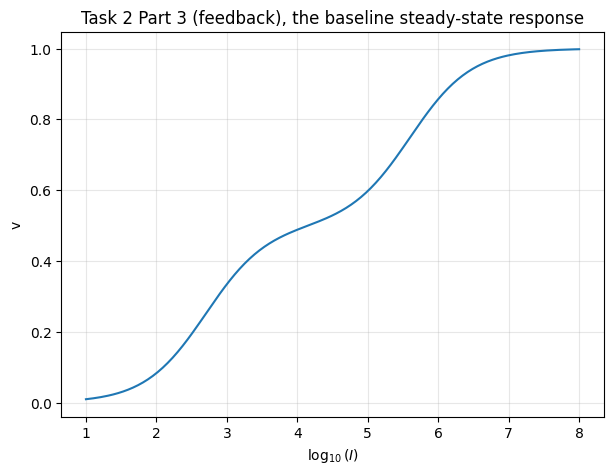

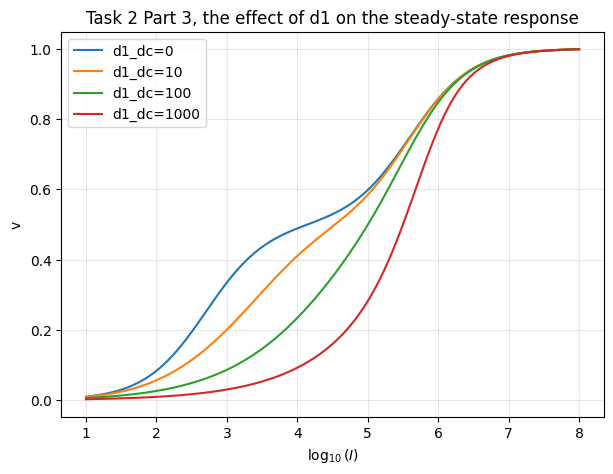

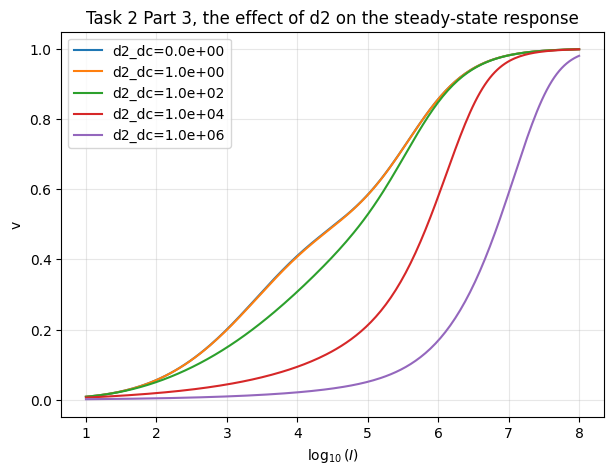

In [16]:
#the feedforward is like v(I) = (a0+a1 I+a2 I^2)/(c0+c1 I+c2 I^2)
# and then the normalization is something as follows: set c2=a2 so v ranges ~[0,1] (lecture suggestion).
# Feedback: we have something like v(I) = (a0+a1 I+a2 I^2)/(c0+c1 I+c2 I^2 + d0 + d1 v + d2 v^2)

import numpy as np
import matplotlib.pyplot as plt

#intensity grid
logI = np.linspace(1, 8, 200)#log10(I)
Ivals = 10**logI

#If h1(t) = a1 * (t/tau)*exp(-t/tau), then ∫ h1 = a1*tau.
#If h2(t1,t2) = a2 * 0.0001 * h1(t1)h1(t2), then ∬ h2 = a2*0.0001*(∫h1)^2.

def dc_coeffs(b, A1, A2, tau):
    a0 = b
    a1 = A1 * tau
    a2 = A2 * 1e-4 * (a1**2)
    return a0, a1, a2

#trying to choose a baseline that actually yields a sigmoid on log10(I)
b1 = 0.0
b2 = 1.0

#switchy by emphasizing the nature of the second-order relative to first-order.
A1_num, A2_num, tau1 = 0.01, 50.0, 0.1      # T1
A1_den, A2_den, tau2 = 0.01, 50.0, 0.2      # T2

a0, a1, a2 = dc_coeffs(b1, A1_num, A2_num, tau1)
c0, c1, c2_raw = dc_coeffs(b2, A1_den, A2_den, tau2)

#something about the lecture normalization trick of setthing c2 = a2 (or then scaling v by c2/a2).
c2 = a2
def v_feedforward(I):
    num = a0 + a1*I + a2*(I**2)
    den = c0 + c1*I + c2*(I**2)
    return num / den

#given by the part 3 homework
# h3_1(t) = D1 * (t/0.04) * exp(-t/0.04)  -> d1_dc = ∫ h3_1 = D1*0.04
# h3_2(t1,t2) = D2 * 0.0001 * h3_1(t1) h3_1(t2) -> d2_dc = D2*0.0001*(d1_dc)^2
#I believe that d0 is going to end up corresponding to b3
def d_feedback(D1, D2, b3):
    d0 = b3
    d1_dc = D1 * 0.04
    d2_dc = D2 * 1e-4 * (d1_dc**2)
    return d0, d1_dc, d2_dc

def solve_cubic_real_nonneg(coeffs, prev=None):
    roots = np.roots(coeffs)
    real_roots = np.array([r.real for r in roots if abs(r.imag) < 1e-8])
    if real_roots.size == 0:
        r = roots[np.argmin(np.abs(roots.imag))]
        return float(r.real)

    cand = real_roots[real_roots >= 0]
    if cand.size == 0:
        cand = real_roots

    if prev is None:
        return float(np.min(cand))
    return float(cand[np.argmin(np.abs(cand - prev))])

def v_with_feedback(Ivals, D1, D2, b3):
    d0, d1_dc, d2_dc = d_feedback(D1, D2, b3)

    v = np.zeros_like(Ivals, dtype=float)
    prev = None
    for k, I in enumerate(Ivals):
        #We have A and C from a  lecture slide where (A= -(numerator), C = denom_without_feedback + d0)
        num = a0 + a1*I + a2*(I**2)
        den_wo_fb = c0 + c1*I + c2*(I**2)
        A = -num
        C = den_wo_fb + d0

        #our cubic is as follows, something like d2 v^3 + d1 v^2 + C v + A = 0
        coeffs = [d2_dc, d1_dc, C, A]
        v[k] = solve_cubic_real_nonneg(coeffs, prev=prev)
        prev = v[k]
    return v

#essentially our baseline feedback parameters
# We have lecture shows d1 values like 0,10,100,1000 that are going to end up affecting the slope.
b3 = 0.0
D1_base = 0.0
D2_base = 0.0

#the first plot is baseline (with the feedback off)
v0 = v_with_feedback(Ivals, D1_base, D2_base, b3)
plt.figure(figsize=(7,5))
plt.plot(logI, v0)
plt.title("Task 2 Part 3 (feedback), the baseline steady-state response")
plt.xlabel(r"$\log_{10}(I)$")
plt.ylabel("v")
plt.grid(True, alpha=0.3)
plt.show()

#  vary d1
d1_targets = [0, 10, 100, 1000]
D1_sweep = [d/0.04 for d in d1_targets]
plt.figure(figsize=(7,5))
for D1 in D1_sweep:
    v = v_with_feedback(Ivals, D1, D2_base, b3)
    plt.plot(logI, v, label=f"d1_dc={0.04*D1:.0f}")
plt.title("Task 2 Part 3, the effect of d1 on the steady-state response")
plt.xlabel(r"$\log_{10}(I)$")
plt.ylabel("v")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#vary d2
D1_for_d2 = 10/0.04
D2_sweep = [0, 1e2, 1e4, 1e6, 1e8]
plt.figure(figsize=(7,5))
for D2 in D2_sweep:
    v = v_with_feedback(Ivals, D1_for_d2, D2, b3)
    d0, d1_dc, d2_dc = d_feedback(D1_for_d2, D2, b3)
    plt.plot(logI, v, label=f"d2_dc={d2_dc:.1e}")
plt.title("Task 2 Part 3, the effect of d2 on the steady-state response")
plt.xlabel(r"$\log_{10}(I)$")
plt.ylabel("v")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()